<a href="https://colab.research.google.com/github/HugoCrainich/Statistical-Machine-Learning/blob/main/Lab%202/Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# Install the FRED API library
!pip install fredapi

In [20]:
# Install the FRED API library
!pip install fredapi

import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred

# Authenticate
# Replace the string below with YOUR unique API key from fred.stlouisfed.org
fred = Fred(api_key='57cec9c614c908e7326850bd500dd9e7')

In [21]:
# 1. Fetch the data series
print("Fetching data from FRED...")
wages = fred.get_series('AHETPI')
cpi = fred.get_series('CPIAUCSL')

# 2. Combine into a DataFrame
df = pd.DataFrame({'Nominal_Wage': wages, 'CPI': cpi})

# 3. Drop missing values (The wage data starts later than CPI data)
df = df.dropna()

# Inspect the raw data
print(df.head())
print(df.tail())

Fetching data from FRED...
            Nominal_Wage    CPI
1964-01-01          2.50  30.94
1964-02-01          2.50  30.91
1964-03-01          2.51  30.94
1964-04-01          2.52  30.95
1964-05-01          2.52  30.98
            Nominal_Wage      CPI
2025-07-01         31.35  322.132
2025-08-01         31.45  323.364
2025-09-01         31.52  324.368
2025-11-01         31.73  325.031
2025-12-01         31.76  326.030


In [22]:
def get_real_wage(nominal_col, cpi_col):
    """
    Takes a nominal column and a CPI column.
    Returns a new column adjusted for inflation (Real Dollars).
    """
    # 1. Get the CPI of the most recent date (Today's Prices)
    # .iloc[-1] grabs the very last row in the data
    cpi_today = cpi_col.iloc[-1]

    # 2. The Formula: (Nominal / Old_CPI) * CPI_Today
    real_col = (nominal_col / cpi_col) * cpi_today

    return real_col

# Apply the function to create a new column
# We feed the "Machine" our two columns:
df['Real_Wage'] = get_real_wage(df['Nominal_Wage'], df['CPI'])

# Check the result - Notice how Real Wages are different from Nominal!
print(df.tail())


            Nominal_Wage      CPI  Real_Wage
2025-07-01         31.35  322.132  31.729355
2025-08-01         31.45  323.364  31.709292
2025-09-01         31.52  324.368  31.681502
2025-11-01         31.73  325.031  31.827524
2025-12-01         31.76  326.030  31.760000


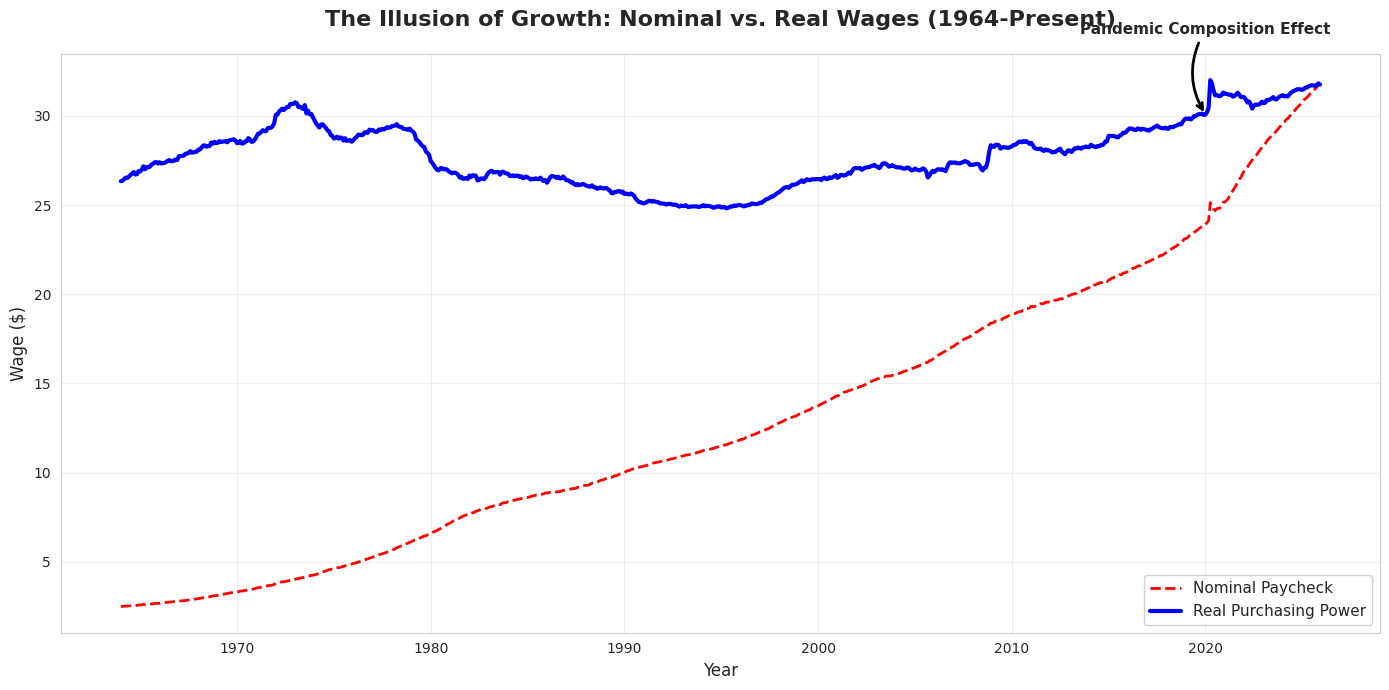

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_style("whitegrid")

# Create figure with specified size
fig, ax = plt.subplots(figsize=(14, 7))

# Plot Nominal Wage as dashed red line
ax.plot(df.index, df['Nominal_Wage'],
        color='red',
        linestyle='--',
        linewidth=2,
        label='Nominal Paycheck')

# Plot Real Wage as thick blue line
ax.plot(df.index, df['Real_Wage'],
        color='blue',
        linewidth=3,
        label='Real Purchasing Power')

# Add title
ax.set_title('The Illusion of Growth: Nominal vs. Real Wages (1964-Present)',
             fontsize=16,
             fontweight='bold',
             pad=20)

# Add axis labels
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Wage ($)', fontsize=12)

# Add annotation for 2020 pandemic spike
# Find the 2020 data point
try:
    spike_year = '2020'
    spike_idx = df.index.year == 2020
    if spike_idx.any():
        spike_date = df.index[spike_idx][0]
        spike_value = df.loc[spike_idx, 'Real_Wage'].iloc[0]

        ax.annotate('Pandemic Composition Effect',
                   xy=(spike_date, spike_value),
                   xytext=(spike_date, spike_value * 1.15),
                   fontsize=11,
                   fontweight='bold',
                   ha='center',
                   arrowprops=dict(arrowstyle='->',
                                 color='black',
                                 lw=2,
                                 connectionstyle='arc3,rad=0.3'))
except:
    # Fallback if 2020 not found - place annotation generically
    print("Note: Could not locate 2020 data point for annotation")

# Add legend
ax.legend(loc='best', fontsize=11, framealpha=0.9)

# Add grid for better readability
ax.grid(True, alpha=0.3)

# Tight layout for better spacing
plt.tight_layout()

# Display the plot
plt.show()

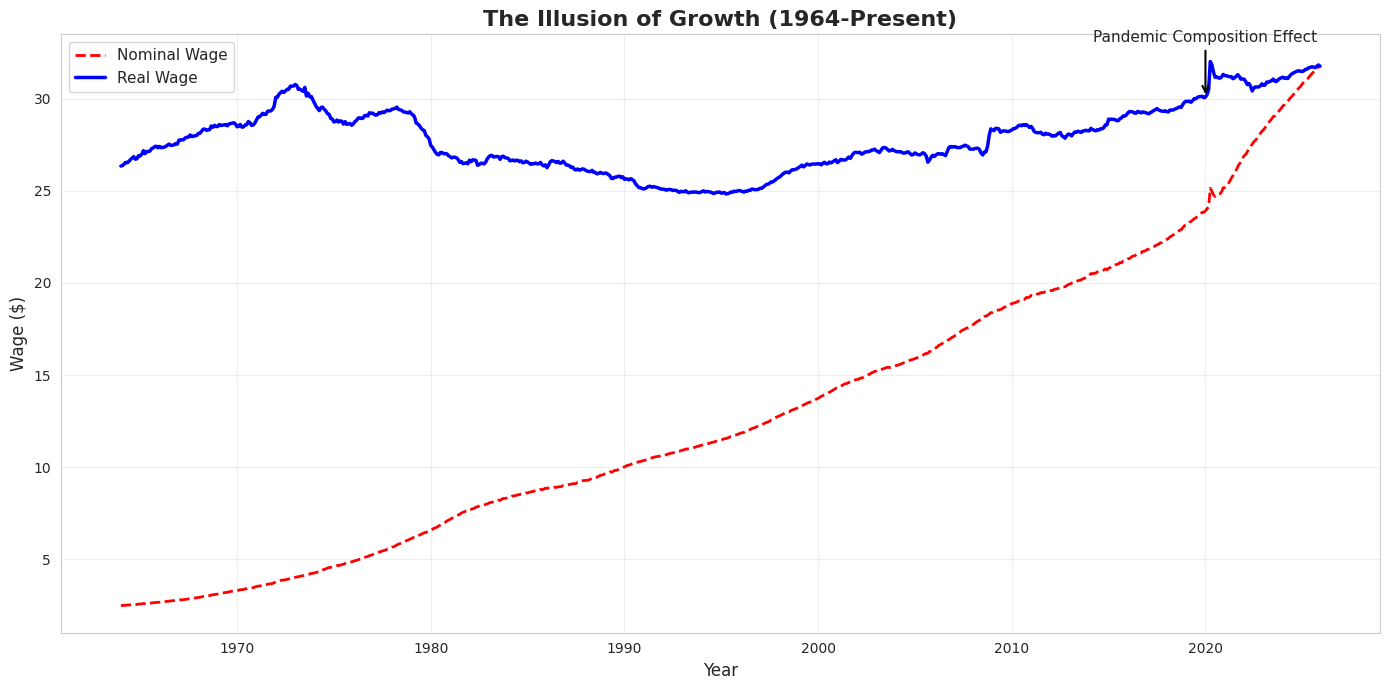

In [24]:
import matplotlib.pyplot as plt

# Create figure with specified size
fig, ax = plt.subplots(figsize=(14, 7))

# Plot Nominal Wage as dashed red line
ax.plot(df.index, df['Nominal_Wage'],
        color='red',
        linestyle='--',
        linewidth=2,
        label='Nominal Wage')

# Plot Real Wage as solid blue line
ax.plot(df.index, df['Real_Wage'],
        color='blue',
        linewidth=2.5,
        label='Real Wage')

# Add title
ax.set_title('The Illusion of Growth (1964-Present)',
             fontsize=16,
             fontweight='bold')

# Add axis labels
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Wage ($)', fontsize=12)

# Add annotation for 2020 pandemic spike
try:
    # Find the 2020 data point
    spike_idx = df.index.year == 2020
    if spike_idx.any():
        spike_date = df.index[spike_idx][0]
        spike_value = df.loc[spike_idx, 'Real_Wage'].iloc[0]

        ax.annotate('Pandemic Composition Effect',
                   xy=(spike_date, spike_value),
                   xytext=(spike_date, spike_value * 1.1),
                   fontsize=11,
                   ha='center',
                   arrowprops=dict(arrowstyle='->',
                                 color='black',
                                 lw=1.5))
except:
    print("Note: Could not locate 2020 data point for annotation")

# Add legend
ax.legend(loc='best', fontsize=11)

# Add grid
ax.grid(True, alpha=0.3)

# Tight layout
plt.tight_layout()

# Display the plot
plt.show()

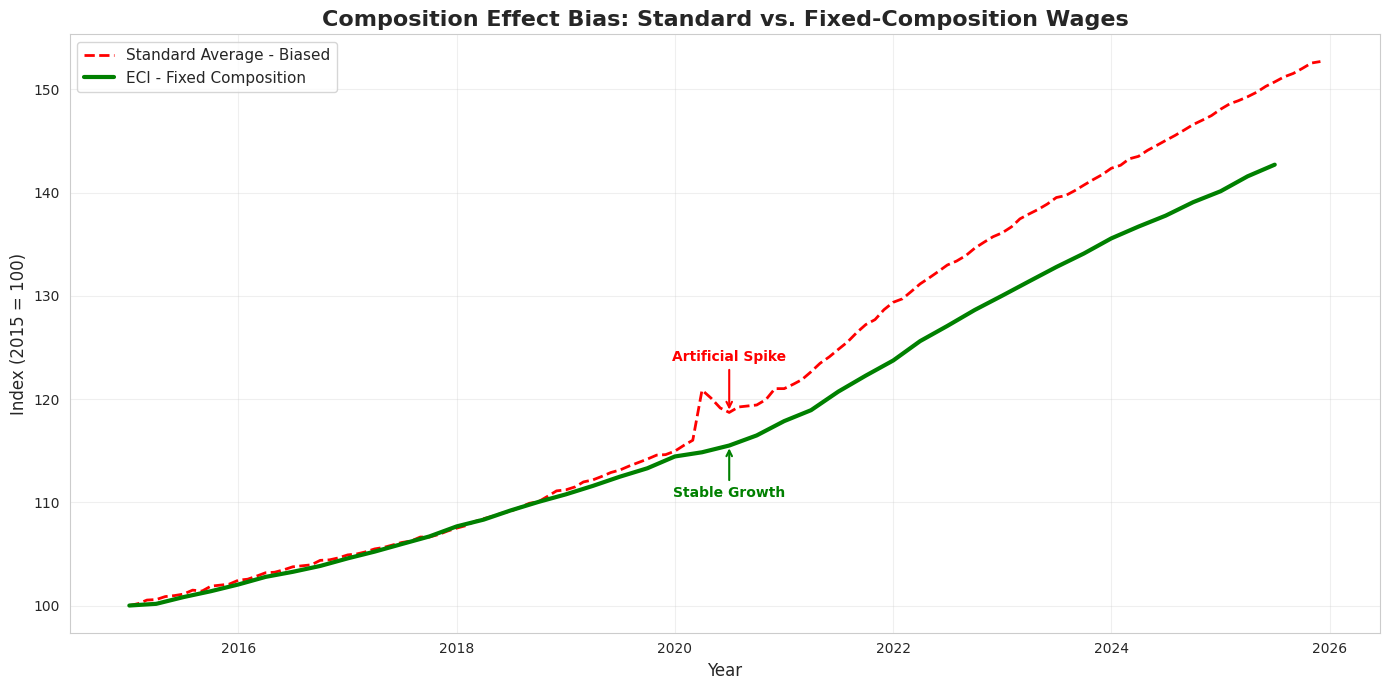

In [25]:
import matplotlib.pyplot as plt

# Fetch Employment Cost Index data
eci = fred.get_series('ECIWAG')

# Filter both series to 2015-01-01 onwards
start_date = '2015-01-01'
wages_filtered = wages[wages.index >= start_date]
eci_filtered = eci[eci.index >= start_date]

# Rebase both series to 100 (first value = 100)
wages_rebased = (wages_filtered / wages_filtered.iloc[0]) * 100
eci_rebased = (eci_filtered / eci_filtered.iloc[0]) * 100

# Create the plot
fig, ax = plt.subplots(figsize=(14, 7))

# Plot standard wages as red dashed line
ax.plot(wages_rebased.index, wages_rebased,
        color='red',
        linestyle='--',
        linewidth=2,
        label='Standard Average - Biased')

# Plot ECI as green thick line
ax.plot(eci_rebased.index, eci_rebased,
        color='green',
        linewidth=3,
        label='ECI - Fixed Composition')

# Add title and labels
ax.set_title('Composition Effect Bias: Standard vs. Fixed-Composition Wages',
             fontsize=16,
             fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Index (2015 = 100)', fontsize=12)

# Add annotation for 2020 divergence
try:
    # Find 2020 data points
    year_2020 = '2020'
    wages_2020_idx = wages_rebased.index.year == 2020
    eci_2020_idx = eci_rebased.index.year == 2020

    if wages_2020_idx.any() and eci_2020_idx.any():
        # Get mid-year 2020 point for annotation
        wages_2020_date = wages_rebased.index[wages_2020_idx][len(wages_rebased.index[wages_2020_idx])//2]
        eci_2020_date = eci_rebased.index[eci_2020_idx][len(eci_rebased.index[eci_2020_idx])//2]

        wages_2020_value = wages_rebased.loc[wages_2020_date]
        eci_2020_value = eci_rebased.loc[eci_2020_date]

        # Annotate the artificial spike in standard wages
        ax.annotate('Artificial Spike',
                   xy=(wages_2020_date, wages_2020_value),
                   xytext=(wages_2020_date, wages_2020_value + 5),
                   fontsize=10,
                   fontweight='bold',
                   color='red',
                   ha='center',
                   arrowprops=dict(arrowstyle='->',
                                 color='red',
                                 lw=1.5))

        # Annotate the stable growth in ECI
        ax.annotate('Stable Growth',
                   xy=(eci_2020_date, eci_2020_value),
                   xytext=(eci_2020_date, eci_2020_value - 5),
                   fontsize=10,
                   fontweight='bold',
                   color='green',
                   ha='center',
                   arrowprops=dict(arrowstyle='->',
                                 color='green',
                                 lw=1.5))
except:
    print("Note: Could not locate 2020 data for annotations")

# Add legend
ax.legend(loc='best', fontsize=11)

# Add grid
ax.grid(True, alpha=0.3)

# Tight layout
plt.tight_layout()

# Display the plot
plt.show()